# Dashboard scripts

Code to help setup data and optimize for the dashboard, which shows a notional race by using my 4 sessions with the same start time, for 4 different karts.

In [1]:
import pandas as pd
import glob
import os

# Define the directory where the files are located
directory_path = '.'  # Current directory

# Find all .csv files in the specified directory
all_files = glob.glob(os.path.join(directory_path, "*.csv"))

# Create an empty list to store the dataframes
df_list = []

# Loop through each file
for file in all_files:
    # Read the file into a dataframe
    df = pd.read_csv(file)

    # Extract the filename and remove the .csv extension
    file_name = os.path.basename(file)
    kart_value = os.path.splitext(file_name)[0]

    # Add the 'Kart' column with the extracted value
    df['Kart'] = kart_value

    # Append the dataframe to the list
    df_list.append(df)

# Concatenate all dataframes in the list into a single dataframe
combined_df = pd.concat(df_list, ignore_index=True)

# Display the first few rows of the combined dataframe to verify
print("Combined DataFrame head:")
print(combined_df.head())

# Optional: Save the combined dataframe to a new CSV file
output_file_name = 'combined_telemetry.csv'
combined_df.to_csv(output_file_name, index=False)
print(f"\nSuccessfully combined all CSV files into {output_file_name}")

Combined DataFrame head:
                  time  race_seconds_elapsed  Orientation_yaw  Orientation_qx  \
0  1759446720906922000                  0.00           1.8875        0.768100   
1  1759446720916975900                  0.01           1.8877        0.767637   
2  1759446720927029800                  0.02           1.8871        0.767000   
3  1759446720937085000                  0.03           1.8869        0.766662   
4  1759446720947138800                  0.04           1.8867        0.766537   

   Orientation_qz  Orientation_roll  Orientation_qw  Orientation_qy  \
0        0.243007           -2.7427       -0.001355       -0.592425   
1        0.244568           -2.7391       -0.000598       -0.592385   
2        0.245912           -2.7366       -0.000286       -0.592653   
3        0.246641           -2.7354       -0.000366       -0.592787   
4        0.246796           -2.7356       -0.000677       -0.592884   

   Orientation_pitch                  utc_time  ...  lap_name

## Delta

i have a telemetry file with the following columns. time,race_seconds_elapsed,Orientation_yaw,Orientation_qx,Orientation_qz,Orientation_roll,Orientation_qw,Orientation_qy,Orientation_pitch,utc_time,Compass_magneticBearing,Accelerometer_z,Accelerometer_y,Accelerometer_x,Gyroscope_z,Gyroscope_y,Gyroscope_x,Magnetometer_z,Magnetometer_y,Magnetometer_x,latitude,longitude,speed,bearing,accel_longitudinal,accel_lateral,turn_rate,race,lap,lap_name,sector,sector_time,lap_seconds_elapsed,g_force,g_force_smoothed,speed_mph,Kart

 there is data for 4 different karts, indicated by the Kart column. We will use seconds_elapsed to treat them as together in one race (ignore the time column). I want a delta column added, showing how far back from the leader each kart is. Python script to calculate it and update the telemetry csv (just adding the delta column). the leader will have a delta of 0. how is this calculated since it's a windy track?


Since all karts have the same race_seconds_elapsed at each time point, we need to determine who's ahead by distance traveled, not by lap time.

Since your data has latitude and longitude, we can calculate the cumulative distance traveled by each kart and use that to determine the leader and the delta in terms of distance.

In [2]:
import pandas as pd
import numpy as np
from math import sin, cos, sqrt, atan2, radians

def haversine_distance(lat1, lon1, lat2, lon2):
    """Calculate the distance between two GPS points in meters using the Haversine formula"""
    # Approximate radius of earth in meters
    R = 6371000.0
    
    # Convert degrees to radians
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    distance = R * c
    
    return distance

def calculate_distance_traveled(df):
    """Calculate cumulative distance traveled for each kart"""
    # Group by kart
    karts = df['Kart'].unique()
    
    # Initialize a distance traveled column
    df['distance_traveled'] = 0.0
    
    for kart in karts:
        kart_data = df[df['Kart'] == kart].sort_values('race_seconds_elapsed')
        
        # Calculate distance between consecutive points
        prev_lat, prev_lon = None, None
        cum_distance = 0.0
        
        for idx, row in kart_data.iterrows():
            if prev_lat is not None and prev_lon is not None:
                # Calculate distance from previous point
                dist = haversine_distance(prev_lat, prev_lon, row['latitude'], row['longitude'])
                cum_distance += dist
            
            # Store cumulative distance
            df.loc[idx, 'distance_traveled'] = cum_distance
            
            # Update previous position
            prev_lat, prev_lon = row['latitude'], row['longitude']
    
    return df

def calculate_delta(input_file, output_file):
    print(f"Loading telemetry data from {input_file}...")
    # Read the telemetry data
    df = pd.read_csv(input_file)
    
    # Calculate distance traveled by each kart
    print("Calculating distance traveled...")
    df = calculate_distance_traveled(df)
    
    # Initialize delta column
    df['delta'] = 0.0
    
    print("Calculating time deltas...")
    # Group by race_seconds_elapsed
    grouped = df.groupby('race_seconds_elapsed')
    
    # For each time point, calculate delta from leader
    for time, group in grouped:
        # Find the kart with maximum distance traveled (the leader)
        max_distance = group['distance_traveled'].max()
        
        # Calculate delta for each kart at this time point
        for idx in group.index:
            distance_behind = max_distance - df.loc[idx, 'distance_traveled']
            
            # Convert distance to time using current speed
            # speed is in units specified in your data, convert if necessary
            # If 'speed' is in m/s, we can directly use it
            # If 'speed' is in mph, convert to m/s first
            if 'speed_mph' in df.columns:
                speed_mps = df.loc[idx, 'speed_mph'] * 0.44704  # mph to m/s
            elif 'speed' in df.columns:
                # Assuming speed is in m/s, adjust if it's in a different unit
                speed_mps = df.loc[idx, 'speed']
            else:
                speed_mps = 10.0  # Default fallback speed if no speed column exists
            
            # Avoid division by zero
            if speed_mps > 0:
                time_delta = distance_behind / speed_mps
            else:
                time_delta = 0
                
            # Round to 3 decimal places
            df.loc[idx, 'delta'] = round(time_delta, 3)
    
    # Write the updated dataframe to a new CSV
    print(f"Writing output to {output_file}...")
    df.to_csv(output_file, index=False)
    print("Done!")

if __name__ == "__main__":
    input_file = "telemetry.csv"  # Change to your input file name
    output_file = "telemetry_with_delta.csv"  # Output file name
    calculate_delta(input_file, output_file)

Loading telemetry data from telemetry.csv...
Calculating distance traveled...
Calculating time deltas...
Writing output to telemetry_with_delta.csv...
Done!


In [4]:
import csv

def add_car_id_to_csv(input_file, output_file, car_id, id_column_name='id'):
    """
    Add the same car ID to every row in a CSV file.
    
    Args:
        input_file (str): Path to the input CSV file
        output_file (str): Path to the output CSV file
        car_id: The car ID value to add to each row (can be string or number)
        id_column_name (str): Name for the ID column (default: 'car_id')
    """
    try:
        # Open the input file
        with open(input_file, 'r', newline='') as infile:
            reader = csv.reader(infile)
            
            # Read the header and add the ID column name
            header = next(reader)
            header.insert(0, id_column_name)
            
            # Prepare to write the output file
            with open(output_file, 'w', newline='') as outfile:
                writer = csv.writer(outfile)
                writer.writerow(header)
                
                # Add the same car ID to each row and write it
                row_count = 0
                for row in reader:
                    row.insert(0, car_id)
                    writer.writerow(row)
                    row_count += 1
                
        print(f"Successfully added car ID '{car_id}' to {input_file} and saved as {output_file}")
        print(f"Processed {row_count} rows")
        
    except FileNotFoundError:
        print(f"Error: Could not find the file {input_file}")
    except Exception as e:
        print(f"Error: {e}")

# Example usage
add_car_id_to_csv('phoebe.csv', 'phoebe_telemetry.csv', car_id='kate')

Successfully added car ID 'kate' to phoebe.csv and saved as phoebe_telemetry.csv
Processed 60375 rows


## race track analysis

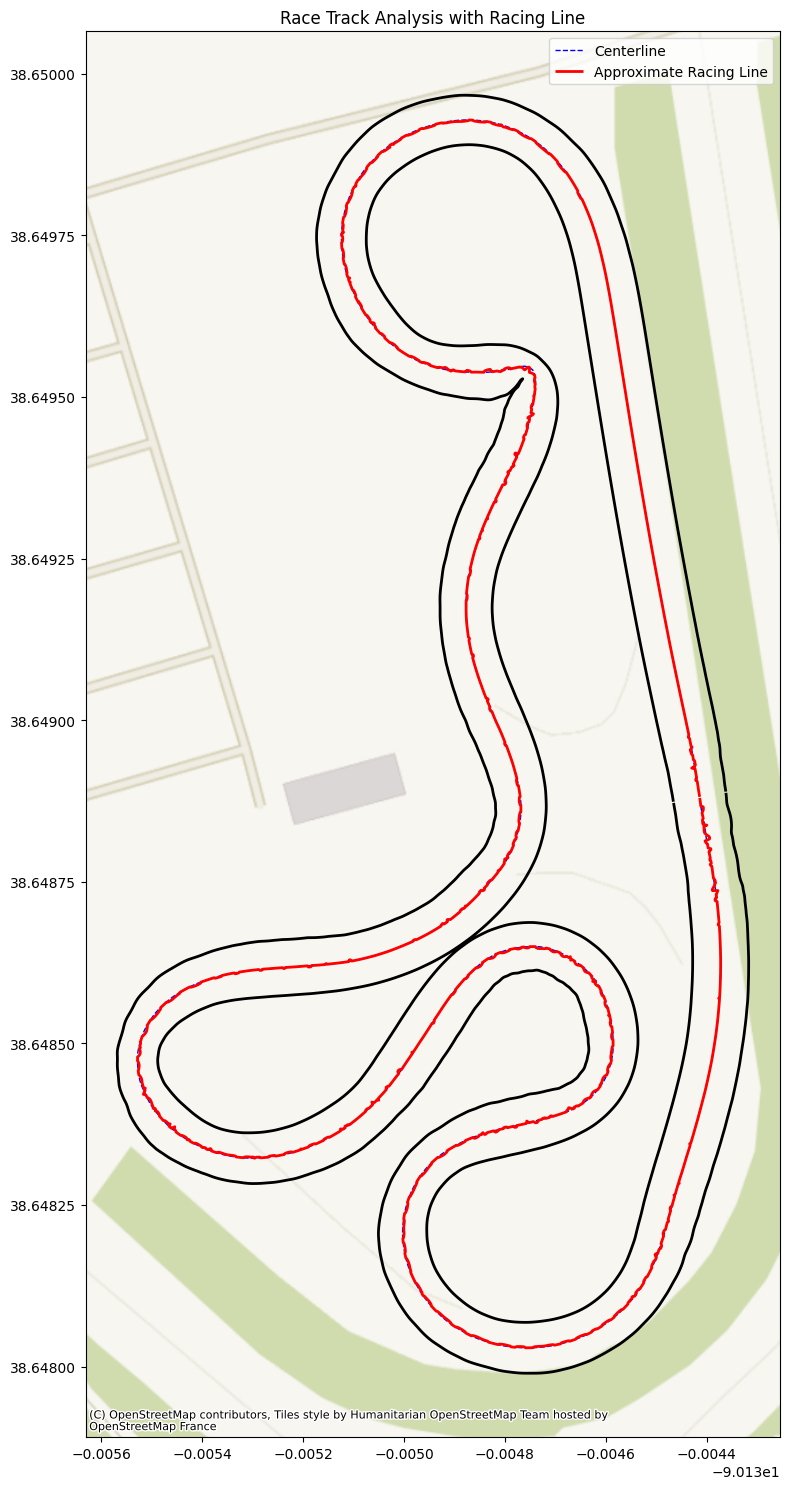

Track analysis complete! Racing line generated and saved.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import LineString, Point
import geopandas as gpd
import contextily as ctx
from scipy.spatial import distance
import math

# Load the track boundary data
df = pd.read_csv('../track.csv')

# Split into inner and outer traces
inner_df = df[df['trace_type'] == 'inner']
outer_df = df[df['trace_type'] == 'outer']

# Convert to GeoDataFrames for easier spatial analysis
inner_line = LineString(list(zip(inner_df['longitude'], inner_df['latitude'])))
outer_line = LineString(list(zip(outer_df['longitude'], outer_df['latitude'])))

# Create a GeoDataFrame for visualization
track_gdf = gpd.GeoDataFrame(
    {'trace_type': ['inner', 'outer']},
    geometry=[inner_line, outer_line],
    crs="EPSG:4326"
)

# Convert to Web Mercator projection for consistent distance calculations
track_gdf = track_gdf.to_crs(epsg=3857)

# Generate points along the track centerline (approximate racing line)
def generate_centerline(inner_line, outer_line, num_points=500):
    # Resample both lines to have equal number of points
    inner_coords = np.array(inner_line.coords)
    outer_coords = np.array(outer_line.coords)
    
    # Simple centerline calculation (midpoint between inner and outer)
    # This is a basic approach - a true racing line would need more sophistication
    centerline_points = []
    
    # Use the shorter of the two boundaries to avoid index errors
    min_length = min(len(inner_coords), len(outer_coords))
    
    # For each point along the track
    for i in range(min_length):
        inner_point = inner_coords[i]
        outer_point = outer_coords[i]
        
        # Calculate midpoint (basic centerline)
        midpoint = [(inner_point[0] + outer_point[0])/2, 
                    (inner_point[1] + outer_point[1])/2]
        centerline_points.append(midpoint)
    
    return LineString(centerline_points)

# For a better racing line, we can shift the centerline toward the inside of corners
def generate_racing_line(centerline, inner_line, outer_line, corner_bias=0.3):
    # This is a simplified approach - real racing lines are more complex
    # and depend on car characteristics, speed, etc.
    
    centerline_coords = np.array(centerline.coords)
    racing_line_points = []
    
    # Calculate curvature at each point along centerline
    curvatures = calculate_curvature(centerline_coords)
    
    # Normalize curvatures to range [-1, 1]
    max_curve = max(abs(np.array(curvatures)))
    if max_curve > 0:
        norm_curvatures = [c / max_curve for c in curvatures]
    else:
        norm_curvatures = curvatures
    
    # For each point, shift toward inside of curve based on curvature
    for i in range(len(centerline_coords)):
        if i > 0 and i < len(centerline_coords) - 1:
            curvature = norm_curvatures[i]
            
            # Determine inside vs outside based on curvature sign
            if abs(curvature) > 0.1:  # Only adjust for significant curves
                # Find closest points on inner and outer boundaries
                inner_point = closest_point_on_line(centerline_coords[i], inner_line)
                outer_point = closest_point_on_line(centerline_coords[i], outer_line)
                
                # Shift toward inside based on curvature
                if curvature > 0:  # Right turn, shift toward inner
                    shift_factor = abs(curvature) * corner_bias
                    new_point = [
                        centerline_coords[i][0] + (inner_point[0] - centerline_coords[i][0]) * shift_factor,
                        centerline_coords[i][1] + (inner_point[1] - centerline_coords[i][1]) * shift_factor
                    ]
                else:  # Left turn, shift toward inner
                    shift_factor = abs(curvature) * corner_bias
                    new_point = [
                        centerline_coords[i][0] + (outer_point[0] - centerline_coords[i][0]) * shift_factor,
                        centerline_coords[i][1] + (outer_point[1] - centerline_coords[i][1]) * shift_factor
                    ]
                racing_line_points.append(new_point)
            else:
                racing_line_points.append(centerline_coords[i])
        else:
            racing_line_points.append(centerline_coords[i])
    
    return LineString(racing_line_points)

def calculate_curvature(points):
    """Calculate curvature at each point in the line"""
    curvatures = [0]  # First point has no curvature
    
    for i in range(1, len(points)-1):
        # Get three consecutive points
        p0 = points[i-1]
        p1 = points[i]
        p2 = points[i+1]
        
        # Calculate vectors
        v1 = [p1[0] - p0[0], p1[1] - p0[1]]
        v2 = [p2[0] - p1[0], p2[1] - p1[1]]
        
        # Calculate angles
        angle1 = math.atan2(v1[1], v1[0])
        angle2 = math.atan2(v2[1], v2[0])
        
        # Calculate curvature (change in angle)
        curvature = (angle2 - angle1)
        
        # Normalize to [-pi, pi]
        if curvature > math.pi:
            curvature -= 2 * math.pi
        elif curvature < -math.pi:
            curvature += 2 * math.pi
            
        curvatures.append(curvature)
    
    curvatures.append(0)  # Last point has no curvature
    return curvatures

def closest_point_on_line(point, line):
    """Find closest point on a line to given point"""
    point_geom = Point(point)
    return list(line.interpolate(line.project(point_geom)).coords)[0]

# Generate centerline
centerline = generate_centerline(track_gdf.geometry[0], track_gdf.geometry[1])
centerline_gdf = gpd.GeoDataFrame(geometry=[centerline], crs="EPSG:3857")

# Generate racing line
racing_line = generate_racing_line(centerline, track_gdf.geometry[0], track_gdf.geometry[1])
racing_line_gdf = gpd.GeoDataFrame(geometry=[racing_line], crs="EPSG:3857")

# Convert back to WGS84 for visualization
track_gdf = track_gdf.to_crs(epsg=4326)
centerline_gdf = centerline_gdf.to_crs(epsg=4326)
racing_line_gdf = racing_line_gdf.to_crs(epsg=4326)

# Visualize
fig, ax = plt.subplots(figsize=(15, 15))

# Plot the track boundaries
track_gdf[track_gdf['trace_type'] == 'inner'].plot(ax=ax, color='black', linewidth=2)
track_gdf[track_gdf['trace_type'] == 'outer'].plot(ax=ax, color='black', linewidth=2)

# Plot the centerline
centerline_gdf.plot(ax=ax, color='blue', linewidth=1, linestyle='--', label='Centerline')

# Plot the racing line
racing_line_gdf.plot(ax=ax, color='red', linewidth=2, label='Approximate Racing Line')

# Add background map
ctx.add_basemap(ax, crs=track_gdf.crs.to_string())

# Add legend
ax.legend()

# Add title
plt.title('Race Track Analysis with Racing Line')
plt.tight_layout()
plt.savefig('race_track_analysis.png', dpi=300)
plt.show()

# Export the racing line to CSV for further use
racing_line_coords = np.array(racing_line.coords)
racing_line_df = pd.DataFrame({
    'longitude': racing_line_coords[:, 0],
    'latitude': racing_line_coords[:, 1],
    'trace_type': 'racing_line'
})
racing_line_df.to_csv('racing_line.csv', index=False)

print("Track analysis complete! Racing line generated and saved.")

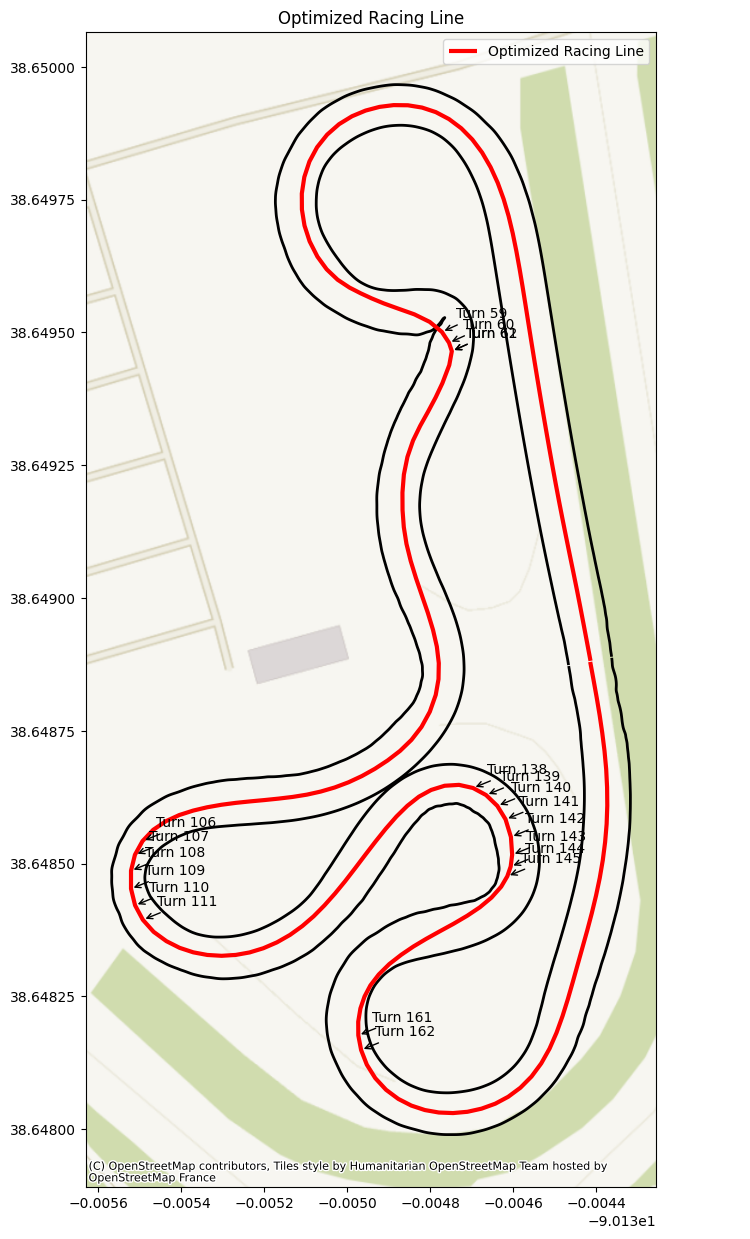

Racing line optimization complete and saved to CSV!


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import LineString, Point
import geopandas as gpd
from scipy.optimize import minimize
import math

# Load the track boundary data
df = pd.read_csv('../track.csv')

# Split into inner and outer traces
inner_df = df[df['trace_type'] == 'inner']
outer_df = df[df['trace_type'] == 'outer']

# Convert to LineString objects
inner_line = LineString(list(zip(inner_df['longitude'], inner_df['latitude'])))
outer_line = LineString(list(zip(outer_df['longitude'], outer_df['latitude'])))

# Create track segment points (divide track into segments)
def create_track_segments(inner_line, outer_line, num_segments=100):
    # Sample points along inner and outer boundaries
    inner_points = [inner_line.interpolate(i/num_segments, normalized=True) 
                   for i in range(num_segments+1)]
    outer_points = [outer_line.interpolate(i/num_segments, normalized=True) 
                   for i in range(num_segments+1)]
    
    # Create lines connecting inner and outer points (gates)
    gates = []
    for i in range(num_segments+1):
        gates.append(LineString([inner_points[i], outer_points[i]]))
    
    return gates

# Calculate path length (approximation of time if constant speed)
def calculate_path_length(points):
    total_length = 0
    for i in range(len(points)-1):
        total_length += math.sqrt(
            (points[i+1][0] - points[i][0])**2 + 
            (points[i+1][1] - points[i][1])**2
        )
    return total_length

# Minimize the path length with curvature penalty
def optimize_racing_line(gates, smoothness_weight=0.5):
    # Initial racing line (midpoints of gates)
    initial_points = [list(LineString(list(gate.coords)).centroid.coords)[0] for gate in gates]
    
    # Convert to optimization variables (percentages along each gate)
    gate_percentages = [0.5] * len(gates)  # Start with midpoints (50%)
    
    # Define objective function to minimize
    def objective(percentages):
        # Generate points along racing line using percentages
        points = []
        for i, gate in enumerate(gates):
            start, end = list(gate.coords)
            p = percentages[i]
            # Ensure percentage is within [0, 1]
            p = max(0.01, min(0.99, p))
            # Calculate point along the gate
            point = (
                start[0] + p * (end[0] - start[0]),
                start[1] + p * (end[1] - start[1])
            )
            points.append(point)
        
        # Calculate path length
        path_length = calculate_path_length(points)
        
        # Calculate curvature penalty (to avoid sharp turns)
        curvature_penalty = 0
        for i in range(1, len(points)-1):
            # Vector from previous to current
            v1 = (
                points[i][0] - points[i-1][0],
                points[i][1] - points[i-1][1]
            )
            # Vector from current to next
            v2 = (
                points[i+1][0] - points[i][0],
                points[i+1][1] - points[i][1]
            )
            
            # Normalize vectors
            v1_mag = math.sqrt(v1[0]**2 + v1[1]**2)
            v2_mag = math.sqrt(v2[0]**2 + v2[1]**2)
            
            if v1_mag > 0 and v2_mag > 0:
                v1_norm = (v1[0]/v1_mag, v1[1]/v1_mag)
                v2_norm = (v2[0]/v2_mag, v2[1]/v2_mag)
                
                # Dot product of normalized vectors
                dot_product = v1_norm[0]*v2_norm[0] + v1_norm[1]*v2_norm[1]
                # Clamp to avoid numerical issues
                dot_product = max(-1.0, min(1.0, dot_product))
                # Angle between vectors
                angle = math.acos(dot_product)
                
                # Add to curvature penalty
                curvature_penalty += angle**2
        
        # Combined objective
        return path_length + smoothness_weight * curvature_penalty
    
    # Bounds for optimization (0-1 for each percentage)
    bounds = [(0.01, 0.99) for _ in range(len(gates))]
    
    # Run optimization
    result = minimize(
        objective, 
        gate_percentages,
        method='L-BFGS-B', 
        bounds=bounds,
        options={'maxiter': 500}
    )
    
    # Generate optimized racing line points
    optimized_percentages = result.x
    optimized_points = []
    for i, gate in enumerate(gates):
        start, end = list(gate.coords)
        p = max(0.01, min(0.99, optimized_percentages[i]))
        point = (
            start[0] + p * (end[0] - start[0]),
            start[1] + p * (end[1] - start[1])
        )
        optimized_points.append(point)
    
    return optimized_points

# Create track segments
gates = create_track_segments(inner_line, outer_line, num_segments=200)

# Optimize racing line
racing_line_points = optimize_racing_line(gates, smoothness_weight=0.7)

# Create GeoDataFrame with racing line
racing_line = LineString(racing_line_points)
racing_line_gdf = gpd.GeoDataFrame(
    {'type': ['racing_line']},
    geometry=[racing_line],
    crs="EPSG:4326"
)

# Create GeoDataFrame with track boundaries
track_gdf = gpd.GeoDataFrame(
    {'trace_type': ['inner', 'outer']},
    geometry=[inner_line, outer_line],
    crs="EPSG:4326"
)

# Visualize
fig, ax = plt.subplots(figsize=(15, 15))
track_gdf[track_gdf['trace_type'] == 'inner'].plot(ax=ax, color='black', linewidth=2)
# Continuing from previous code

track_gdf[track_gdf['trace_type'] == 'outer'].plot(ax=ax, color='black', linewidth=2)
racing_line_gdf.plot(ax=ax, color='red', linewidth=3, label='Optimized Racing Line')

# Add annotations for key track features
# Find areas of high curvature in the racing line
curvatures = []
for i in range(1, len(racing_line_points)-1):
    p0 = racing_line_points[i-1]
    p1 = racing_line_points[i]
    p2 = racing_line_points[i+1]
    
    # Calculate vectors
    v1 = (p1[0] - p0[0], p1[1] - p0[1])
    v2 = (p2[0] - p1[0], p2[1] - p1[1])
    
    # Calculate angles
    angle1 = math.atan2(v1[1], v1[0])
    angle2 = math.atan2(v2[1], v2[0])
    
    # Calculate curvature (change in angle)
    curvature = abs(angle2 - angle1)
    
    # Normalize to [0, pi]
    if curvature > math.pi:
        curvature = 2*math.pi - curvature
        
    curvatures.append(curvature)

# Label significant corners
threshold = np.percentile(curvatures, 90)  # Top 10% of curvatures
for i, curvature in enumerate(curvatures):
    if curvature > threshold:
        idx = i + 1  # Offset for the curvature calculation
        ax.annotate(f'Turn {i+1}', 
                   xy=(racing_line_points[idx][0], racing_line_points[idx][1]),
                   xytext=(10, 10), textcoords='offset points',
                   arrowprops=dict(arrowstyle="->"))

plt.title('Optimized Racing Line')
plt.legend()

# Add basemap if available
try:
    import contextily as ctx
    ctx.add_basemap(ax, crs=track_gdf.crs.to_string())
except:
    print("Contextily not available or basemap could not be added.")

plt.savefig('optimized_racing_line.png', dpi=300)
plt.show()

# Save the racing line to CSV
racing_line_df = pd.DataFrame({
    'longitude': [p[0] for p in racing_line_points],
    'latitude': [p[1] for p in racing_line_points],
    'trace_type': 'racing_line'
})

# Calculate additional racing line metrics
racing_line_df['distance'] = [0] + [
    math.sqrt((racing_line_points[i+1][0] - racing_line_points[i][0])**2 + 
             (racing_line_points[i+1][1] - racing_line_points[i][1])**2)
    for i in range(len(racing_line_points)-1)
]

racing_line_df['cumulative_distance'] = racing_line_df['distance'].cumsum()

# Add curvature data
racing_line_df['curvature'] = [0] + curvatures + [0]

racing_line_df.to_csv('optimized_racing_line.csv', index=False)
print("Racing line optimization complete and saved to CSV!")

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import LineString, Point, Polygon, MultiLineString
import math
import folium
from folium.plugins import HeatMap
import branca.colormap as cm

# Load the track boundary data
df = pd.read_csv('../track_cleaned.csv')

# Split into inner and outer traces
inner_df = df[df['trace_type'] == 'inner']
outer_df = df[df['trace_type'] == 'outer']

# Make sure data is ordered correctly (important for LineString creation)
inner_df = inner_df.sort_values(by=['latitude', 'longitude'])
outer_df = outer_df.sort_values(by=['latitude', 'longitude'])

# Create LineStrings
inner_line = LineString(list(zip(inner_df['longitude'], inner_df['latitude'])))
outer_line = LineString(list(zip(outer_df['longitude'], outer_df['latitude'])))

# Create track sectors by dividing the track into segments
def create_track_sectors(inner_line, outer_line, num_sectors=8):
    # Sample points along inner and outer boundaries
    inner_points = [inner_line.interpolate(i/num_sectors, normalized=True) 
                   for i in range(num_sectors+1)]
    outer_points = [outer_line.interpolate(i/num_sectors, normalized=True) 
                   for i in range(num_sectors+1)]
    
    # Create sector polygons
    sectors = []
    for i in range(num_sectors):
        # Create polygon for each sector
        points = [
            inner_points[i],
            inner_points[i+1],
            outer_points[i+1],
            outer_points[i]
        ]
        sector = Polygon([p.coords[0] for p in points])
        sectors.append(sector)
    
    return sectors

# Generate racing line (reusing previously defined function)
# Let's create a simpler version for this example
def generate_simple_racing_line(inner_line, outer_line, num_points=200):
    inner_points = [inner_line.interpolate(i/num_points, normalized=True) 
                   for i in range(num_points)]
    outer_points = [outer_line.interpolate(i/num_points, normalized=True) 
                   for i in range(num_points)]
    
    # Calculate midpoints with some adjustments for corners
    racing_line_points = []
    for i in range(num_points):
        inner_p = inner_points[i].coords[0]
        outer_p = outer_points[i].coords[0]
        
        # Basic method: calculate midpoint with slight bias
        # In a real implementation, use curvature to adjust this
        bias = 0.5  # 0.5 = perfect midpoint, <0.5 = inside bias, >0.5 = outside bias
        
        # For simplicity we'll use local curvature approximation
        if i > 0 and i < num_points-1:
            prev_mid = [(inner_points[i-1].x + outer_points[i-1].x)/2,
                        (inner_points[i-1].y + outer_points[i-1].y)/2]
            curr_mid = [(inner_p[0] + outer_p[0])/2,
                        (inner_p[1] + outer_p[1])/2]
            next_mid = [(inner_points[i+1].x + outer_points[i+1].x)/2,
                        (inner_points[i+1].y + outer_points[i+1].y)/2]
            
            # Calculate vectors
            v1 = (curr_mid[0] - prev_mid[0], curr_mid[1] - prev_mid[1])
            v2 = (next_mid[0] - curr_mid[0], next_mid[1] - curr_mid[1])
            
            # Estimate curvature by angle change
            dot_product = v1[0]*v2[0] + v1[1]*v2[1]
            v1_mag = math.sqrt(v1[0]**2 + v1[1]**2)
            v2_mag = math.sqrt(v2[0]**2 + v2[1]**2)
            
            if v1_mag > 0 and v2_mag > 0:
                # Approximate turning
                cos_angle = max(-1.0, min(1.0, dot_product / (v1_mag * v2_mag)))
                angle = math.acos(cos_angle)
                
                # Adjust bias based on curvature - move toward inside of corners
                if angle > 0.1:  # Only adjust for significant turns
                    # Simple heuristic: sharper turn = more inside bias
                    bias = max(0.2, 0.5 - angle / math.pi)
        
        point = (inner_p[0] + bias * (outer_p[0] - inner_p[0]),
                 inner_p[1] + bias * (outer_p[1] - inner_p[1]))
        racing_line_points.append(point)
    
    return LineString(racing_line_points)

# Create track sectors
sectors = create_track_sectors(inner_line, outer_line, num_sectors=8)
sectors_gdf = gpd.GeoDataFrame(
    {'sector': range(1, len(sectors)+1)},
    geometry=sectors,
    crs="EPSG:4326"
)

# Generate a simple racing line
racing_line = generate_simple_racing_line(inner_line, outer_line)
racing_line_gdf = gpd.GeoDataFrame(
    {'type': ['racing_line']},
    geometry=[racing_line],
    crs="EPSG:4326"
)

# Calculate sector characteristics
sector_data = []
for i, sector in enumerate(sectors):
    # Get the portion of racing line in this sector
    sector_racing_line = racing_line.intersection(sector)
    
    if not sector_racing_line.is_empty:
        # Calculate length
        length = sector_racing_line.length
        
        # Extract coordinates properly - handling MultiLineString case
        coords = []
        if isinstance(sector_racing_line, LineString):
            coords = list(sector_racing_line.coords)
        elif isinstance(sector_racing_line, MultiLineString):
            # Handle MultiLineString by extracting coords from each part
            for line in sector_racing_line.geoms:
                coords.extend(list(line.coords))
        elif isinstance(sector_racing_line, Point):
            # Handle Point case
            coords = [sector_racing_line.coords[0]]
        
        # Skip curvature calculation if we don't have enough points
        if len(coords) < 3:
            avg_curvature = 0
            max_curvature = 0
        else:
            curvatures = []
            for j in range(1, len(coords)-1):
                p0 = coords[j-1]
                p1 = coords[j]
                p2 = coords[j+1]
                
                # Calculate vectors
                v1 = (p1[0] - p0[0], p1[1] - p0[1])
                v2 = (p2[0] - p1[0], p2[1] - p1[1])
                
                # Skip if vectors are too small (avoid division by zero)
                v1_mag = math.sqrt(v1[0]**2 + v1[1]**2)
                v2_mag = math.sqrt(v2[0]**2 + v2[1]**2)
                
                if v1_mag < 1e-10 or v2_mag < 1e-10:
                    continue
                
                # Calculate angles
                angle1 = math.atan2(v1[1], v1[0])
                angle2 = math.atan2(v2[1], v2[0])
                
                # Calculate curvature (change in angle)
                curvature = abs(angle2 - angle1)
                
                # Normalize to [0, pi]
                if curvature > math.pi:
                    curvature = 2*math.pi - curvature
                    
                curvatures.append(curvature)
            
            avg_curvature = np.mean(curvatures) if curvatures else 0
            max_curvature = np.max(curvatures) if curvatures else 0
        
        sector_data.append({
            'sector': i+1,
            'length': length,
            'avg_curvature': avg_curvature,
            'max_curvature': max_curvature,
            'sector_type': 'High-speed' if avg_curvature < 0.1 else 
                          ('Technical' if avg_curvature > 0.2 else 'Mixed')
        })

sector_df = pd.DataFrame(sector_data)

# Create an interactive map with track analysis
center = [(inner_df['latitude'].min() + outer_df['latitude'].max()) / 2,
         (inner_df['longitude'].min() + outer_df['longitude'].max()) / 2]

m = folium.Map(location=center, zoom_start=15)

# Add the track boundaries
folium.GeoJson(
    inner_line.__geo_interface__,
    name="Inner Boundary",
    style_function=lambda x: {"color": "black", "weight": 2}
).add_to(m)

folium.GeoJson(
    outer_line.__geo_interface__,
    name="Outer Boundary",
    style_function=lambda x: {"color": "black", "weight": 2}
).add_to(m)

# Add the racing line
folium.GeoJson(
    racing_line.__geo_interface__,
    name="Racing Line",
    style_function=lambda x: {"color": "red", "weight": 3}
).add_to(m)

# Add sectors with coloring based on curvature
colormap = cm.linear.YlOrRd_09.scale(
    sector_df['avg_curvature'].min(),
    sector_df['avg_curvature'].max()
)

for idx, row in sectors_gdf.iterrows():
    sector_info = sector_df[sector_df['sector'] == row['sector']].iloc[0]
    
    folium.GeoJson(
        row.geometry.__geo_interface__,
        name=f"Sector {row['sector']}",
        style_function=lambda x, c=colormap(sector_info['avg_curvature']): {
            "fillColor": c,
            "color": "black",
            "weight": 1,
            "fillOpacity": 0.5
        },
        tooltip=folium.Tooltip(
            f"Sector {row['sector']}<br>"
            f"Length: {sector_info['length']:.1f} meters<br>"
            f"Avg Curvature: {sector_info['avg_curvature']:.3f}<br>"
            f"Type: {sector_info['sector_type']}"
        )
    ).add_to(m)

# Add a legend
colormap.caption = 'Average Curvature'
m.add_child(colormap)

# Save the map
m.save('track_analysis_map.html')

# Also create a static visualization
fig, ax = plt.subplots(figsize=(15, 15))

# Plot the track boundaries
gpd.GeoDataFrame(geometry=[inner_line], crs="EPSG:4326").plot(ax=ax, color='black', linewidth=2)
gpd.GeoDataFrame(geometry=[outer_line], crs="EPSG:4326").plot(ax=ax, color='black', linewidth=2)

# Plot the sectors with color based on curvature
sectors_gdf.plot(
    ax=ax,
    column=[sector_df[sector_df['sector'] == i+1]['avg_curvature'].values[0] if i+1 in sector_df['sector'].values else 0 
            for i in range(len(sectors))],
    legend=True,
    alpha=0.5,
    cmap='YlOrRd',
    legend_kwds={'label': 'Average Curvature'}
)

# Plot the racing line
racing_line_gdf.plot(ax=ax, color='red', linewidth=3)

# Label each sector
for idx, row in sectors_gdf.iterrows():
    centroid = row.geometry.centroid
    if row['sector'] in sector_df['sector'].values:
        sector_info = sector_df[sector_df['sector'] == row['sector']].iloc[0]
        ax.text(centroid.x, centroid.y, 
               f"S{row['sector']}\n{sector_info['sector_type']}",
               fontsize=9, ha='center')
    else:
        ax.text(centroid.x, centroid.y, 
               f"S{row['sector']}",
               fontsize=9, ha='center')

plt.title('Track Analysis with Racing Line and Sector Classification')
plt.savefig('track_analysis.png', dpi=300)
plt.show()

# Export analysis data
sector_df.to_csv('track_sector_analysis.csv', index=False)
print("Track analysis complete! Results saved.")

GEOSException: TopologyException: side location conflict at -90.134877134218797 38.648345135703941. This can occur if the input geometry is invalid.

## check for overlap

Loading track data...
Total points: 8432
Trace types: ['inner' 'outer']
Inner boundary points: 4216
Outer boundary points: 4216
Inner boundary duplicate points: 0
Outer boundary duplicate points: 0

Checking geometry validity...
Inner line valid: True
Outer line valid: True
Inner line is simple: True
Outer line is simple: True
Inner and outer lines intersect: False

Checking for problematic consecutive points...
Found 3702 potential issues in inner boundary
First 5 issues: [(125, 126, 9.98883660370328e-07), (126, 127, 9.97202785725365e-07), (127, 128, 9.955231716332216e-07), (128, 129, 9.93844846757748e-07), (129, 130, 9.921678355226423e-07)]
Found 3546 potential issues in outer boundary
First 5 issues: [(242, 243, 9.98700824796226e-07), (243, 244, 9.971192812982167e-07), (244, 245, 9.955393570526714e-07), (245, 246, 9.93961041192923e-07), (246, 247, 9.923842724950397e-07)]

Creating visualization...


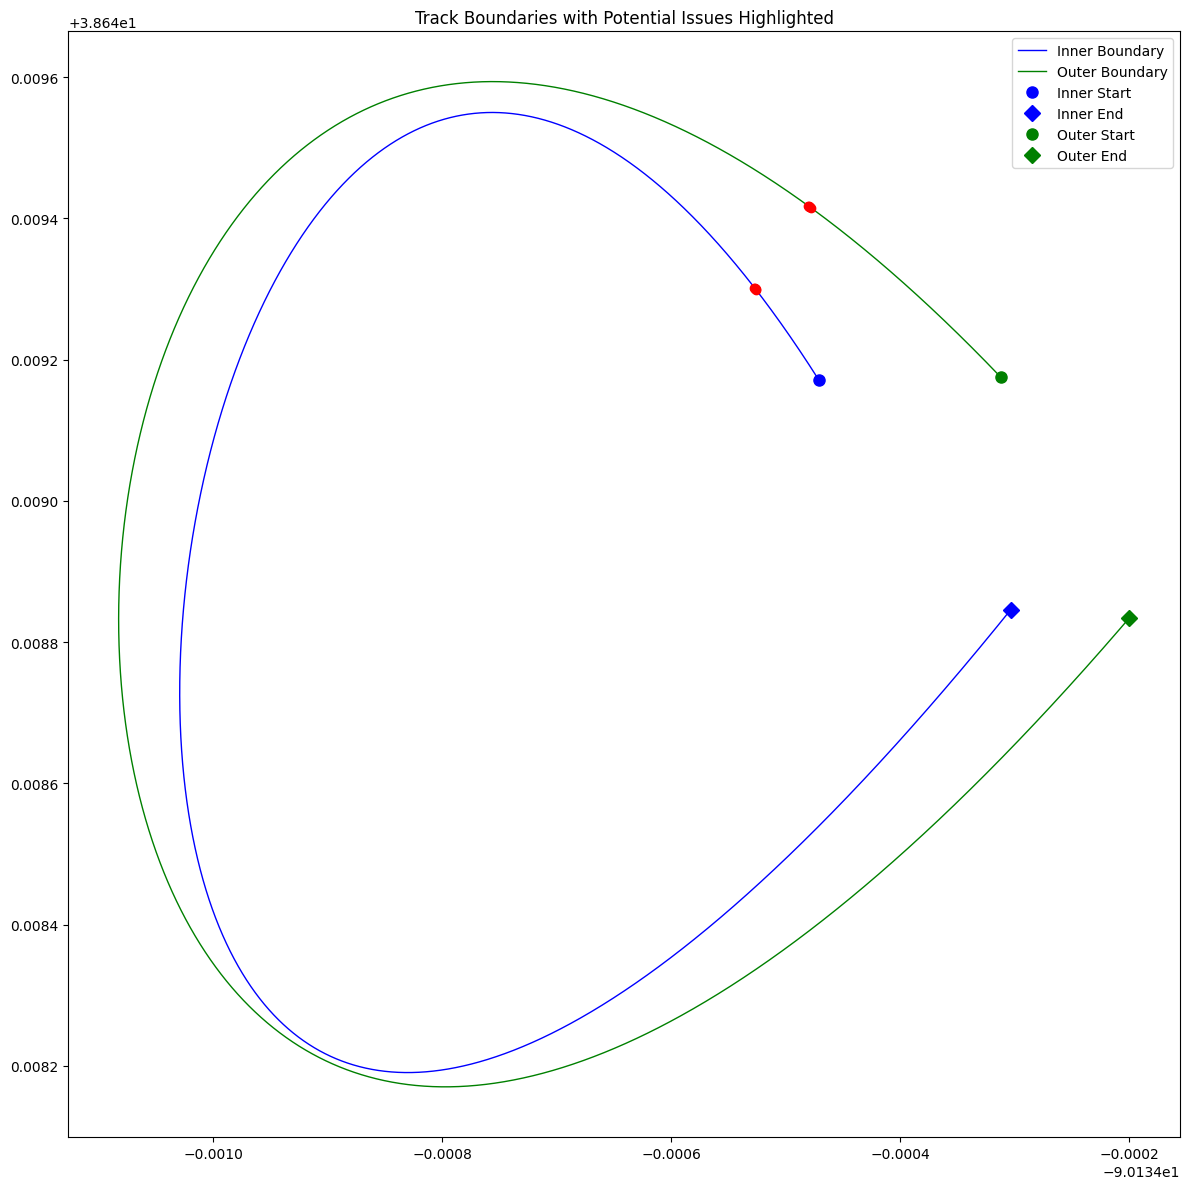


Suggestions to fix issues:
1. Remove duplicate points
2. Ensure the track boundaries don't intersect except at start/end
3. Fix areas where points are too close together
4. Ensure the track is properly oriented (inner and outer boundaries are consistent)
5. Check for sharp angles or spikes in the boundary

Creating cleaned track data...
Original inner points: 4216, Cleaned: 4216
Original outer points: 4216, Cleaned: 4216
Cleaned track data saved to ../track_cleaned.csv


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import LineString, Point
import geopandas as gpd
from shapely.validation import explain_validity

# Load the track boundary data
print("Loading track data...")
df = pd.read_csv('../track_smoothed_cleaned.csv')

print(f"Total points: {len(df)}")
print(f"Trace types: {df['trace_type'].unique()}")

# Split into inner and outer traces
inner_df = df[df['trace_type'] == 'inner']
outer_df = df[df['trace_type'] == 'outer']

print(f"Inner boundary points: {len(inner_df)}")
print(f"Outer boundary points: {len(outer_df)}")

# Check for duplicate points
inner_duplicates = inner_df.duplicated(subset=['latitude', 'longitude'])
outer_duplicates = outer_df.duplicated(subset=['latitude', 'longitude'])

print(f"Inner boundary duplicate points: {inner_duplicates.sum()}")
print(f"Outer boundary duplicate points: {outer_duplicates.sum()}")

# Create LineStrings for the boundaries
inner_line = LineString(list(zip(inner_df['longitude'], inner_df['latitude'])))
outer_line = LineString(list(zip(outer_df['longitude'], outer_df['latitude'])))

# Check if the LineStrings are valid
print("\nChecking geometry validity...")
print(f"Inner line valid: {inner_line.is_valid}")
if not inner_line.is_valid:
    print(f"Inner line issue: {explain_validity(inner_line)}")
    
print(f"Outer line valid: {outer_line.is_valid}")
if not outer_line.is_valid:
    print(f"Outer line issue: {explain_validity(outer_line)}")

# Check if the lines are simple (no self-intersections)
print(f"Inner line is simple: {inner_line.is_simple}")
print(f"Outer line is simple: {outer_line.is_simple}")

# Check if the inner line intersects with the outer line (should only at start/end for closed tracks)
print(f"Inner and outer lines intersect: {inner_line.intersects(outer_line)}")
if inner_line.intersects(outer_line):
    intersection = inner_line.intersection(outer_line)
    print(f"Number of intersection points: {len(intersection.geoms) if hasattr(intersection, 'geoms') else 1}")

# Check for consecutive points that are too close (potential causes for numerical issues)
def check_consecutive_points(df, min_distance=1e-6):
    issues = []
    for i in range(len(df) - 1):
        lat1, lon1 = df.iloc[i][['latitude', 'longitude']]
        lat2, lon2 = df.iloc[i+1][['latitude', 'longitude']]
        
        # Simple Euclidean distance (good enough for small distances)
        dist = np.sqrt((lon2 - lon1)**2 + (lat2 - lat1)**2)
        
        if dist < min_distance:
            issues.append((i, i+1, dist))
    
    return issues

print("\nChecking for problematic consecutive points...")
inner_issues = check_consecutive_points(inner_df)
print(f"Found {len(inner_issues)} potential issues in inner boundary")
if inner_issues:
    print(f"First 5 issues: {inner_issues[:5]}")
    
outer_issues = check_consecutive_points(outer_df)
print(f"Found {len(outer_issues)} potential issues in outer boundary")
if outer_issues:
    print(f"First 5 issues: {outer_issues[:5]}")

# Create a visualization to see the track
print("\nCreating visualization...")
fig, ax = plt.subplots(figsize=(12, 12))

# Plot the track boundaries
ax.plot(inner_df['longitude'], inner_df['latitude'], 'b-', linewidth=1, label='Inner Boundary')
ax.plot(outer_df['longitude'], outer_df['latitude'], 'g-', linewidth=1, label='Outer Boundary')

# Highlight the start/end points
ax.plot(inner_df['longitude'].iloc[0], inner_df['latitude'].iloc[0], 'bo', markersize=8, label='Inner Start')
ax.plot(inner_df['longitude'].iloc[-1], inner_df['latitude'].iloc[-1], 'bD', markersize=8, label='Inner End')
ax.plot(outer_df['longitude'].iloc[0], outer_df['latitude'].iloc[0], 'go', markersize=8, label='Outer Start')
ax.plot(outer_df['longitude'].iloc[-1], outer_df['latitude'].iloc[-1], 'gD', markersize=8, label='Outer End')

# If there are intersections, highlight them
if inner_line.intersects(outer_line):
    intersection = inner_line.intersection(outer_line)
    if hasattr(intersection, 'geoms'):
        for point in intersection.geoms:
            ax.plot(point.x, point.y, 'rx', markersize=10)
    else:
        ax.plot(intersection.x, intersection.y, 'rx', markersize=10, label='Intersection')

# Highlight potential problem areas
for i, j, dist in inner_issues[:5]:
    ax.plot(inner_df['longitude'].iloc[i], inner_df['latitude'].iloc[i], 'ro', markersize=6)
    
for i, j, dist in outer_issues[:5]:
    ax.plot(outer_df['longitude'].iloc[i], outer_df['latitude'].iloc[i], 'ro', markersize=6)

ax.set_title('Track Boundaries with Potential Issues Highlighted')
ax.legend()

plt.tight_layout()
plt.savefig('track_topology_check.png')
plt.show()

# Suggest fixes
print("\nSuggestions to fix issues:")
print("1. Remove duplicate points")
print("2. Ensure the track boundaries don't intersect except at start/end")
print("3. Fix areas where points are too close together")
print("4. Ensure the track is properly oriented (inner and outer boundaries are consistent)")
print("5. Check for sharp angles or spikes in the boundary")

# Create clean versions of the track
def clean_track_data(df):
    # Remove duplicates
    df_clean = df.drop_duplicates(subset=['latitude', 'longitude'])
    
    # Could add more cleaning steps here
    return df_clean

print("\nCreating cleaned track data...")
inner_clean = clean_track_data(inner_df)
outer_clean = clean_track_data(outer_df)

print(f"Original inner points: {len(inner_df)}, Cleaned: {len(inner_clean)}")
print(f"Original outer points: {len(outer_df)}, Cleaned: {len(outer_clean)}")

# Save cleaned data
cleaned_df = pd.concat([
    inner_clean,
    outer_clean
])
cleaned_df.to_csv('../track_cleaned.csv', index=False)
print("Cleaned track data saved to ../track_cleaned.csv")

## smooth topology

Loading track data...
Inner boundary points: 4216
Outer boundary points: 4216
Found 0 sharp angles in inner boundary
After initial smoothing: 0 sharp angles remain


KeyboardInterrupt: 

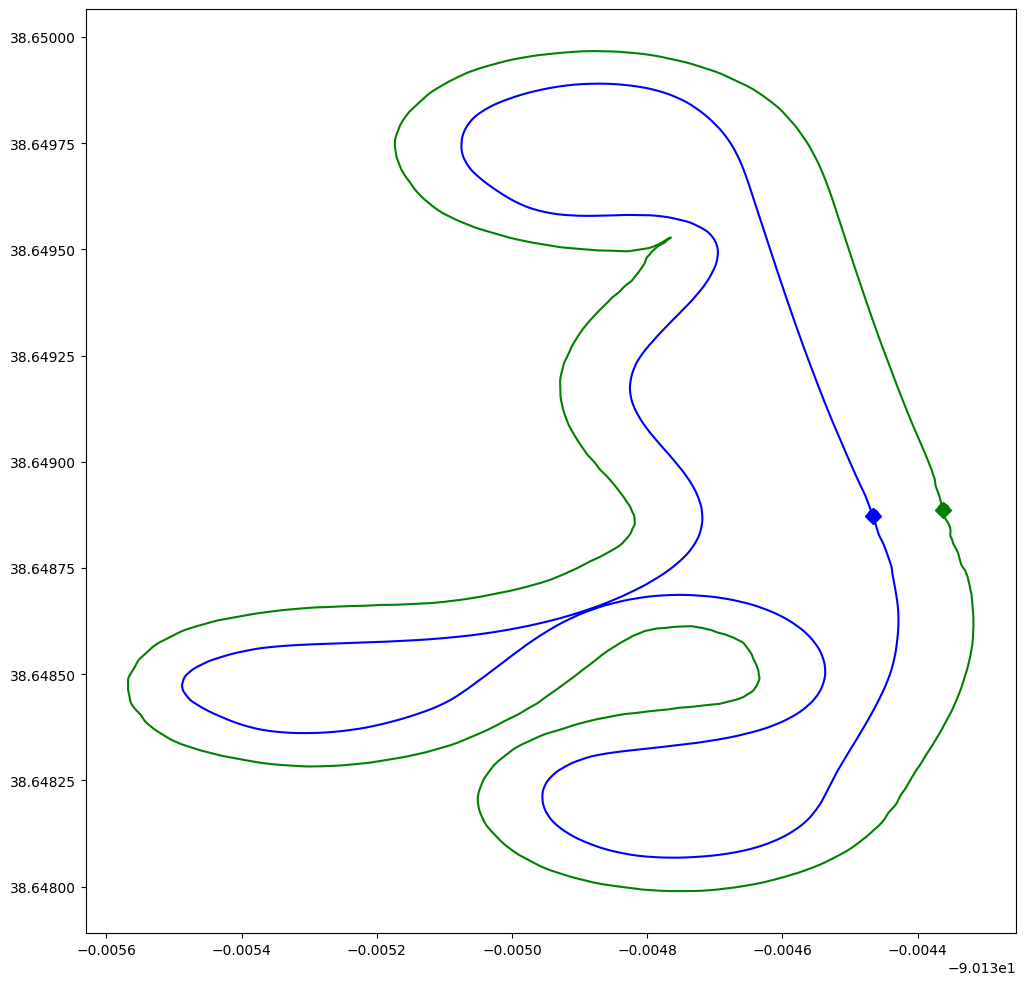

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import splprep, splev
from shapely.geometry import LineString, Point
import math

# Load the track boundary data
print("Loading track data...")
df = pd.read_csv('../track.csv')

# Split into inner and outer traces
inner_df = df[df['trace_type'] == 'inner']
outer_df = df[df['trace_type'] == 'outer']

print(f"Inner boundary points: {len(inner_df)}")
print(f"Outer boundary points: {len(outer_df)}")

# Plot original data
plt.figure(figsize=(12, 12))
plt.plot(inner_df['longitude'], inner_df['latitude'], 'b-', label='Inner Boundary (Original)')
plt.plot(outer_df['longitude'], outer_df['latitude'], 'g-', label='Outer Boundary')

# Plot start/end points
plt.plot(inner_df['longitude'].iloc[0], inner_df['latitude'].iloc[0], 'bo', markersize=8, label='Inner Start')
plt.plot(inner_df['longitude'].iloc[-1], inner_df['latitude'].iloc[-1], 'bD', markersize=8, label='Inner End')
plt.plot(outer_df['longitude'].iloc[0], outer_df['latitude'].iloc[0], 'go', markersize=8, label='Outer Start')
plt.plot(outer_df['longitude'].iloc[-1], outer_df['latitude'].iloc[-1], 'gD', markersize=8, label='Outer End')

# Function to detect potential issues (sharp angles)
def detect_sharp_angles(coords, threshold_angle=30):
    """Detect sharp angles in a line"""
    issues = []
    
    for i in range(1, len(coords)-1):
        p0 = coords[i-1]
        p1 = coords[i]
        p2 = coords[i+1]
        
        # Calculate vectors
        v1 = (p1[0] - p0[0], p1[1] - p0[1])
        v2 = (p2[0] - p1[0], p2[1] - p1[1])
        
        # Calculate magnitudes
        v1_mag = math.sqrt(v1[0]**2 + v1[1]**2)
        v2_mag = math.sqrt(v2[0]**2 + v2[1]**2)
        
        # Skip if vectors are too small
        if v1_mag < 1e-10 or v2_mag < 1e-10:
            continue
        
        # Normalize vectors
        v1_norm = (v1[0]/v1_mag, v1[1]/v1_mag)
        v2_norm = (v2[0]/v2_mag, v2[1]/v2_mag)
        
        # Calculate dot product
        dot_product = v1_norm[0]*v2_norm[0] + v1_norm[1]*v2_norm[1]
        dot_product = max(-1.0, min(1.0, dot_product))
        
        # Calculate angle in degrees
        angle = math.degrees(math.acos(dot_product))
        
        if angle > threshold_angle:
            issues.append((i, angle))
    
    return issues

# Get inner boundary coordinates
inner_coords = list(zip(inner_df['longitude'], inner_df['latitude']))

# Detect sharp angles
sharp_angles = detect_sharp_angles(inner_coords, threshold_angle=60)
print(f"Found {len(sharp_angles)} sharp angles in inner boundary")

if sharp_angles:
    print("Top 5 sharpest angles:")
    for idx, (i, angle) in enumerate(sorted(sharp_angles, key=lambda x: x[1], reverse=True)[:5]):
        print(f"  {idx+1}. Point {i}: {angle:.1f} degrees at ({inner_coords[i][0]}, {inner_coords[i][1]})")
        # Mark these points on the plot
        plt.plot(inner_coords[i][0], inner_coords[i][1], 'rx', markersize=10)

# Function to smooth a boundary using spline interpolation
def smooth_boundary(coords, smoothing_factor=0.0, num_points=None):
    """Smooth a boundary using spline interpolation"""
    if num_points is None:
        num_points = len(coords)
    
    # Extract x and y coordinates
    x = [p[0] for p in coords]
    y = [p[1] for p in coords]
    
    # Generate a spline representation
    tck, u = splprep([x, y], s=smoothing_factor, per=0)
    
    # Evaluate the spline at equally spaced points
    u_new = np.linspace(0, 1, num_points)
    x_new, y_new = splev(u_new, tck)
    
    return list(zip(x_new, y_new))

# Alternative approach: manually fix problematic areas
def fix_problematic_area(coords, problem_start, problem_end, buffer=5):
    """Replace a problematic section with a smoothed version"""
    # Add buffer around problem area
    start_idx = max(0, problem_start - buffer)
    end_idx = min(len(coords) - 1, problem_end + buffer)
    
    # Extract the section to be smoothed
    section = coords[start_idx:end_idx+1]
    
    # Smooth just this section
    smoothed_section = smooth_boundary(section, smoothing_factor=1.0)
    
    # Replace in the original coordinates
    new_coords = coords.copy()
    new_coords[start_idx:end_idx+1] = smoothed_section
    
    return new_coords

# First try smoothing the entire inner boundary with a small factor
smoothed_inner_coords = smooth_boundary(inner_coords, smoothing_factor=0.5)

# Find sharp angles that might still remain
remaining_sharp_angles = detect_sharp_angles(smoothed_inner_coords, threshold_angle=60)
print(f"After initial smoothing: {len(remaining_sharp_angles)} sharp angles remain")

# If we still have sharp angles, try targeted smoothing
if remaining_sharp_angles:
    # Group consecutive sharp angles
    groups = []
    current_group = [remaining_sharp_angles[0][0]]
    
    for i in range(1, len(remaining_sharp_angles)):
        current_idx = remaining_sharp_angles[i][0]
        prev_idx = remaining_sharp_angles[i-1][0]
        
        if current_idx - prev_idx <= 3:  # Consider consecutive if within 3 points
            current_group.append(current_idx)
        else:
            groups.append(current_group)
            current_group = [current_idx]
    
    if current_group:
        groups.append(current_group)
    
    print(f"Found {len(groups)} groups of sharp angles to fix")
    
    # Fix each group
    fixed_coords = smoothed_inner_coords
    for group in groups:
        problem_start = min(group)
        problem_end = max(group)
        print(f"Fixing area from index {problem_start} to {problem_end}")
        fixed_coords = fix_problematic_area(fixed_coords, problem_start, problem_end, buffer=10)
    
    smoothed_inner_coords = fixed_coords

# Alternative: manual fix for the specific pointy section
# Let's identify the point that's causing the issue - find the closest point to the outer boundary
def find_closest_to_other_boundary(inner_coords, outer_coords):
    """Find the point on inner boundary closest to outer boundary"""
    min_dist = float('inf')
    min_inner_idx = -1
    min_outer_idx = -1
    
    for i, inner_point in enumerate(inner_coords):
        inner_p = Point(inner_point)
        for j, outer_point in enumerate(outer_coords):
            outer_p = Point(outer_point)
            dist = inner_p.distance(outer_p)
            if dist < min_dist:
                min_dist = dist
                min_inner_idx = i
                min_outer_idx = j
    
    return min_inner_idx, min_outer_idx, min_dist

# Get outer boundary coordinates
outer_coords = list(zip(outer_df['longitude'], outer_df['latitude']))

# Find the closest points between boundaries
min_inner_idx, min_outer_idx, min_dist = find_closest_to_other_boundary(inner_coords, outer_coords)
print(f"Closest points: inner[{min_inner_idx}] to outer[{min_outer_idx}] with distance {min_dist}")

# Mark this point
plt.plot(inner_coords[min_inner_idx][0], inner_coords[min_inner_idx][1], 'ro', markersize=10, label='Closest Point')

# If we've identified a problematic area, specifically smooth it
problem_start = max(0, min_inner_idx - 20)  # 20 points before
problem_end = min(len(inner_coords) - 1, min_inner_idx + 20)  # 20 points after
manually_fixed = fix_problematic_area(inner_coords, problem_start, problem_end, buffer=10)

# Plot the smoothed inner boundary options
plt.plot(
    [p[0] for p in smoothed_inner_coords], 
    [p[1] for p in smoothed_inner_coords], 
    'c-', linewidth=1.5, label='Smoothed Inner Boundary'
)

plt.plot(
    [p[0] for p in manually_fixed], 
    [p[1] for p in manually_fixed], 
    'm-', linewidth=1.5, label='Manually Fixed Boundary'
)

plt.legend()
plt.title('Track Boundaries with Smoothing')
plt.tight_layout()
plt.savefig('smoothed_track.png', dpi=300)
plt.show()

# Create new DataFrames with the smoothed data
# Let's use the manually fixed version as it targets the specific problem
smoothed_inner_df = pd.DataFrame({
    'latitude': [p[1] for p in manually_fixed],
    'longitude': [p[0] for p in manually_fixed],
    'trace_type': 'inner'
})

# Combine with the original outer boundary
smoothed_df = pd.concat([smoothed_inner_df, outer_df])

# Save the smoothed track
smoothed_df.to_csv('../track_smoothed.csv', index=False)
print("Smoothed track saved to '../track_smoothed.csv'")

# Create a second plot to show just the final result
plt.figure(figsize=(12, 12))
plt.plot([p[0] for p in manually_fixed], [p[1] for p in manually_fixed], 'b-', linewidth=2, label='Smoothed Inner Boundary')
plt.plot(outer_df['longitude'], outer_df['latitude'], 'g-', linewidth=2, label='Outer Boundary')
plt.legend()
plt.title('Final Smoothed Track')
plt.tight_layout()
plt.savefig('final_smoothed_track.png', dpi=300)

## reduce unrealistic precision

Loading track data...
Total points: 8432
Trace types: ['outer' 'inner']
Inner points: 4216
Outer points: 4216

Current precision examples:
latitude      38.648889
longitude    -90.134363
trace_type        outer
Name: 0, dtype: object
latitude      38.648891
longitude    -90.134363
trace_type        outer
Name: 1, dtype: object

New precision examples:
latitude      38.648889
longitude    -90.134363
trace_type        outer
Name: 0, dtype: object
latitude      38.648891
longitude    -90.134363
trace_type        outer
Name: 1, dtype: object

Removed 0 duplicate points after rounding

Inner boundary valid: True
Outer boundary valid: True
Inner boundary is simple: True
Outer boundary is simple: True
Boundaries intersect: False


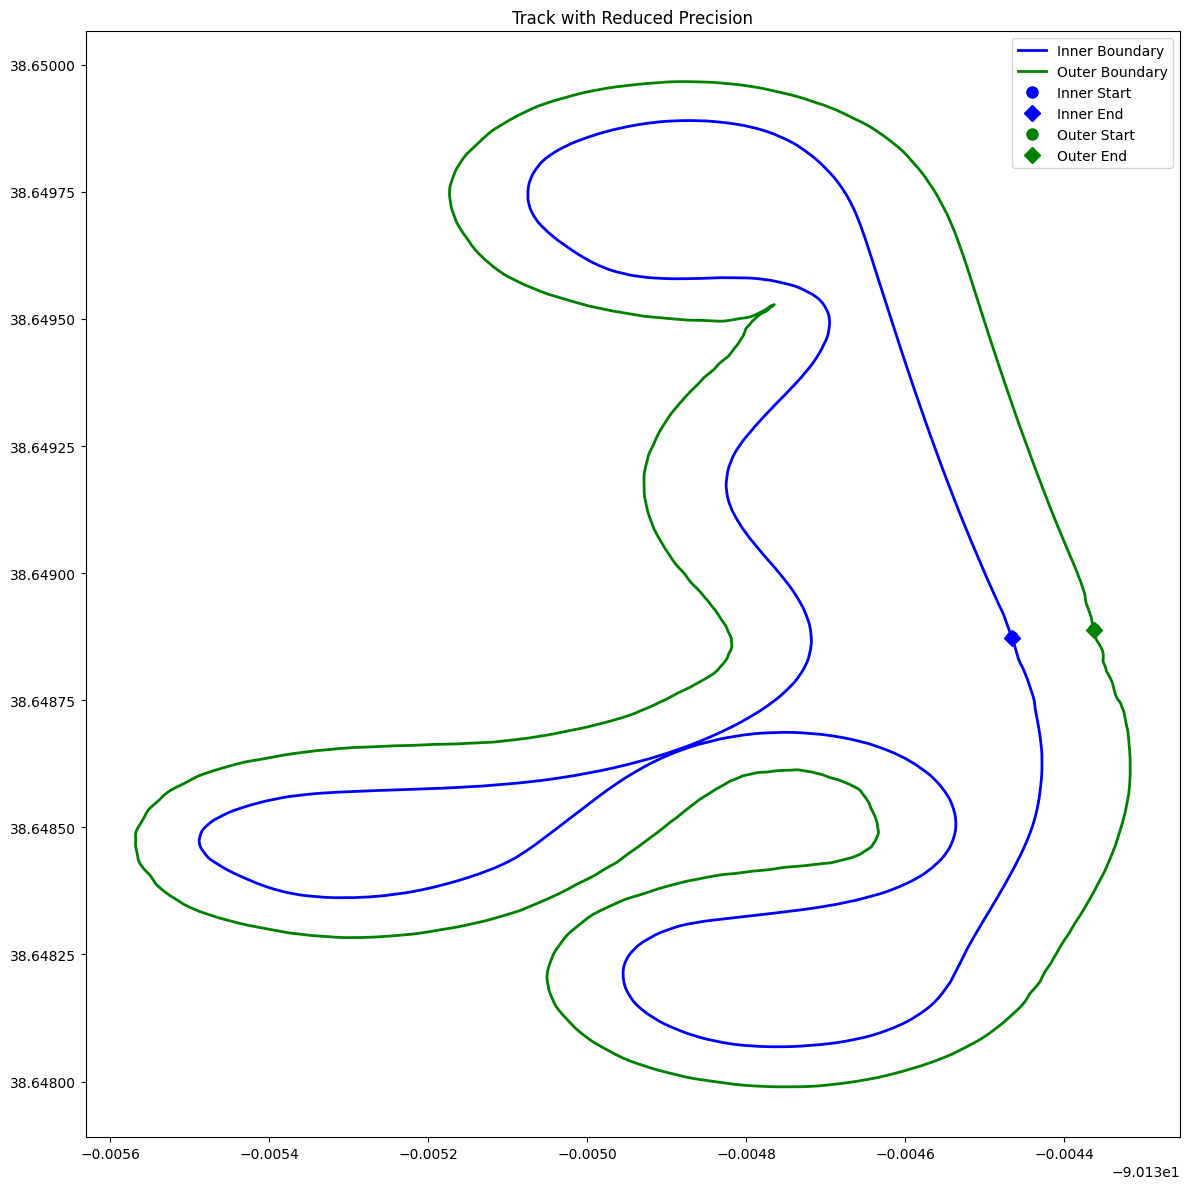


Cleaned track saved to '../track_cleaned.csv'

Smoothed and cleaned track saved to '../track_smoothed_cleaned.csv'


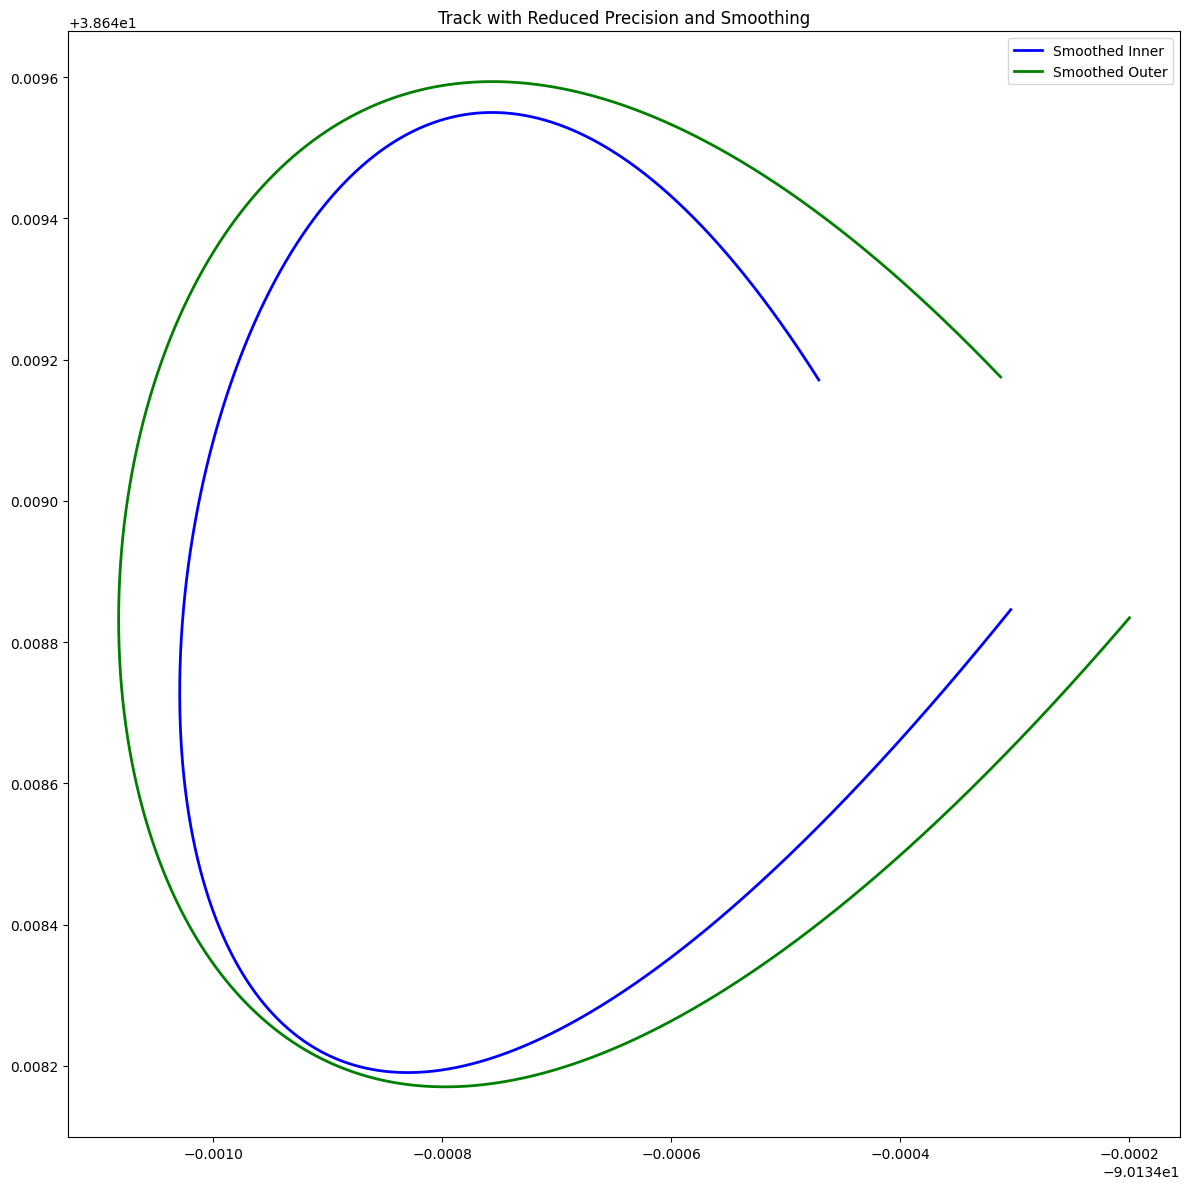

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import LineString, Point
import geopandas as gpd

# Load the track boundary data
print("Loading track data...")
df = pd.read_csv('../track.csv')

# View data statistics
print(f"Total points: {len(df)}")
print(f"Trace types: {df['trace_type'].unique()}")
print(f"Inner points: {len(df[df['trace_type'] == 'inner'])}")
print(f"Outer points: {len(df[df['trace_type'] == 'outer'])}")

# Check current precision
print("\nCurrent precision examples:")
print(df.iloc[0])
print(df.iloc[1])

# Reduce precision to 7 decimal places (approx. 1.1cm precision)
# This is more than adequate for any GPS tracking application
DECIMAL_PRECISION = 7

df['latitude'] = df['latitude'].round(DECIMAL_PRECISION)
df['longitude'] = df['longitude'].round(DECIMAL_PRECISION)

# Check new precision
print("\nNew precision examples:")
print(df.iloc[0])
print(df.iloc[1])

# Remove duplicate points that might now exist due to rounding
old_count = len(df)
df = df.drop_duplicates(subset=['latitude', 'longitude', 'trace_type'])
new_count = len(df)

print(f"\nRemoved {old_count - new_count} duplicate points after rounding")

# Split into inner and outer traces for visualization
inner_df = df[df['trace_type'] == 'inner']
outer_df = df[df['trace_type'] == 'outer']

# Create LineStrings for boundaries
inner_line = LineString(list(zip(inner_df['longitude'], inner_df['latitude'])))
outer_line = LineString(list(zip(outer_df['longitude'], outer_df['latitude'])))

# Check if LineStrings are valid
print(f"\nInner boundary valid: {inner_line.is_valid}")
print(f"Outer boundary valid: {outer_line.is_valid}")

# Check if LineStrings are simple (no self-intersections)
print(f"Inner boundary is simple: {inner_line.is_simple}")
print(f"Outer boundary is simple: {outer_line.is_simple}")

# Check if boundaries intersect
print(f"Boundaries intersect: {inner_line.intersects(outer_line)}")

# Visualize the track with reduced precision
plt.figure(figsize=(12, 12))
plt.plot(inner_df['longitude'], inner_df['latitude'], 'b-', linewidth=2, label='Inner Boundary')
plt.plot(outer_df['longitude'], outer_df['latitude'], 'g-', linewidth=2, label='Outer Boundary')

# Mark start/end points
plt.plot(inner_df['longitude'].iloc[0], inner_df['latitude'].iloc[0], 'bo', markersize=8, label='Inner Start')
plt.plot(inner_df['longitude'].iloc[-1], inner_df['latitude'].iloc[-1], 'bD', markersize=8, label='Inner End')
plt.plot(outer_df['longitude'].iloc[0], outer_df['latitude'].iloc[0], 'go', markersize=8, label='Outer Start')
plt.plot(outer_df['longitude'].iloc[-1], outer_df['latitude'].iloc[-1], 'gD', markersize=8, label='Outer End')

plt.title('Track with Reduced Precision')
plt.legend()
plt.tight_layout()
plt.savefig('track_reduced_precision.png', dpi=300)
plt.show()

# Save the cleaned track data
df.to_csv('../track_cleaned.csv', index=False)
print("\nCleaned track saved to '../track_cleaned.csv'")

# Optional: Do additional smoothing to eliminate any remaining issues
from scipy.interpolate import splprep, splev

# Function to smooth a boundary using spline interpolation
def smooth_boundary(coords, smoothing_factor=0.0, num_points=None):
    """Smooth a boundary using spline interpolation"""
    if num_points is None:
        num_points = len(coords)
    
    # Extract x and y coordinates
    x = [p[0] for p in coords]
    y = [p[1] for p in coords]
    
    # Generate a spline representation
    tck, u = splprep([x, y], s=smoothing_factor, per=0)
    
    # Evaluate the spline at equally spaced points
    u_new = np.linspace(0, 1, num_points)
    x_new, y_new = splev(u_new, tck)
    
    return list(zip(x_new, y_new))

# Apply light smoothing to both boundaries
inner_coords = list(zip(inner_df['longitude'], inner_df['latitude']))
outer_coords = list(zip(outer_df['longitude'], outer_df['latitude']))

smoothed_inner = smooth_boundary(inner_coords, smoothing_factor=0.1)
smoothed_outer = smooth_boundary(outer_coords, smoothing_factor=0.1)

# Create smoothed dataframes
smoothed_inner_df = pd.DataFrame({
    'latitude': [p[1] for p in smoothed_inner],
    'longitude': [p[0] for p in smoothed_inner],
    'trace_type': 'inner'
})

smoothed_outer_df = pd.DataFrame({
    'latitude': [p[1] for p in smoothed_outer],
    'longitude': [p[0] for p in smoothed_outer],
    'trace_type': 'outer'
})

# Combine into a single dataframe
smoothed_df = pd.concat([smoothed_inner_df, smoothed_outer_df])

# Visualize smoothed track
plt.figure(figsize=(12, 12))
plt.plot([p[0] for p in smoothed_inner], [p[1] for p in smoothed_inner], 'b-', linewidth=2, label='Smoothed Inner')
plt.plot([p[0] for p in smoothed_outer], [p[1] for p in smoothed_outer], 'g-', linewidth=2, label='Smoothed Outer')

plt.title('Track with Reduced Precision and Smoothing')
plt.legend()
plt.tight_layout()
plt.savefig('track_smoothed_precision.png', dpi=300)

# Save the smoothed track data
smoothed_df.to_csv('../track_smoothed_cleaned.csv', index=False)
print("\nSmoothed and cleaned track saved to '../track_smoothed_cleaned.csv'")